<a href="https://colab.research.google.com/github/GilangAngga12/pcd/blob/main/pert12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

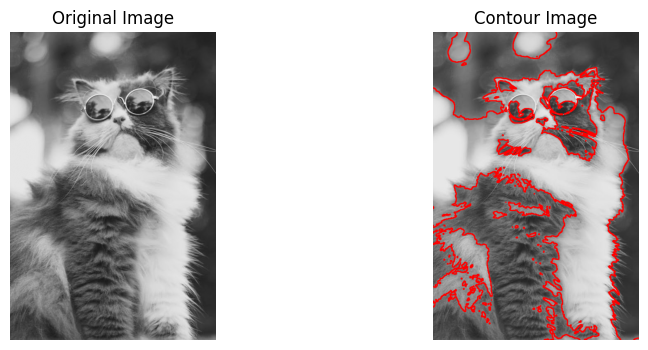

In [3]:
# Ekstraksi Bentuk
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('/content/sample_data/pexels-photo-7944876.jpeg', 0)  # baca file bentuk grayscale

blur = cv2.GaussianBlur(img, (5, 5), 0)     # mengurangi noise menggunakan Gaussian Blur
_, binary = cv2.threshold(blur, 127, 255, cv2.THRESH_BINARY)

edges = cv2.Canny(binary, 100, 200)         # deteksi tepi Canny

contours, _ = cv2.findContours(
    edges,
    cv2.RETR_TREE,
    cv2.CHAIN_APPROX_SIMPLE
)                                            # cari kontur dari deteksi tepi

contour_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
cv2.drawContours(contour_img, contours, -1, (255, 0, 0), 2)  # menggambar kontur

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Contour Image")
plt.imshow(contour_img)
plt.axis('off')

plt.show()

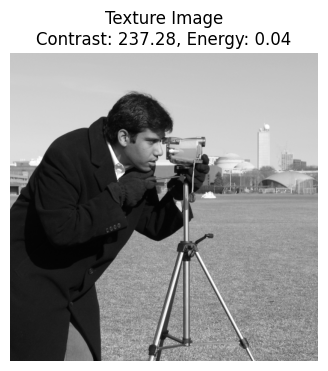

In [6]:
from skimage.feature import graycomatrix, graycoprops
from skimage import data
import matplotlib.pyplot as plt

image = data.camera()

glcm = graycomatrix(image,
                    distances=[1],
                    angles=[0],
                    levels=256,
                    symmetric=True,
                    normed=True
)

# fitur tekstur
contrast = graycoprops(glcm, 'contrast')[0, 0]
energy = graycoprops(glcm, 'energy')[0, 0]

plt.figure(figsize=(5, 4))
plt.title(f"Texture Image\nContrast: {contrast:.2f}, Energy: {energy:.2f}")
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

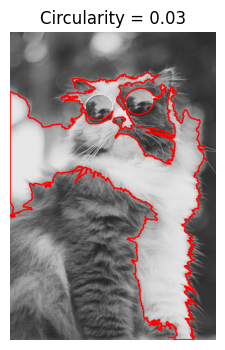

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Memuat gambar
img = cv2.imread('/content/sample_data/pexels-photo-7944876.jpeg', 0) # Menggunakan gambar yang tersedia

# Memeriksa apakah gambar berhasil dimuat
if img is None:
    print("Error: Could not load image. Please check the path.")
else:
    # Melakukan thresholding untuk mengubah gambar menjadi biner (hitam putih)
    _, binary = cv2.threshold(img, 150, 255, cv2.THRESH_BINARY)

    # Mencari kontur pada gambar biner
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Memilih kontur terbesar berdasarkan luas area
    if contours:
        cnt = max(contours, key=cv2.contourArea)

        # Hitung luas dan keliling kontur
        area = cv2.contourArea(cnt)
        perimeter = cv2.arcLength(cnt, True) # Panjang kelilingnya

        # Hitung circularity
        # Rumus: circularity = (4 * pi * area) / (perimeter^2)
        # Menghindari pembagian oleh nol jika perimeter adalah nol
        if perimeter > 0:
            circularity = (4 * np.pi * area) / (perimeter ** 2)
        else:
            circularity = 0.0 # Atau nilai lain yang sesuai jika perimeter nol

        # Menyiapkan output gambar berwarna untuk menggambar kontur
        output = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        cv2.drawContours(output, [cnt], -1, (255, 0, 0), 2)

        # Menampilkan hasil
        plt.figure(figsize=(5, 4))
        plt.title(f"Circularity = {circularity:.2f}")
        plt.imshow(output)
        plt.axis('off')
        plt.show()
    else:
        print("No contours found in the image.")

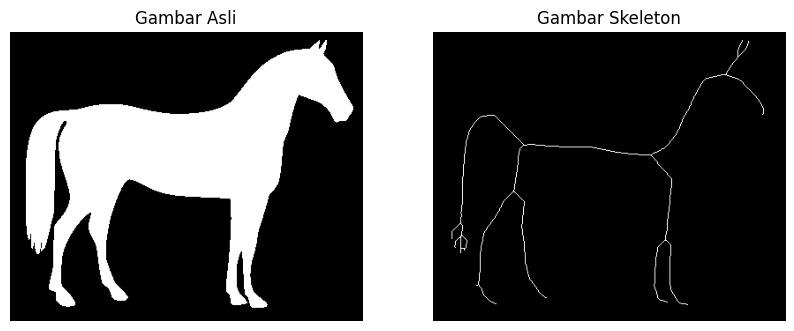

In [12]:
#Skeleton
from skimage.morphology import skeletonize
from skimage import data
from skimage.util import invert
import matplotlib.pyplot as plt
import cv2 as cv

gambar = invert(data.horse())
# gambar = cv.imread("/content/mbak lara croft.jpg", 0) #baca gambar

#Skeletonize itu berguna untuk menghasilkan kerangka objek berupa garis setebal satu piksel
skeleton = skeletonize(gambar)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(gambar, cmap='gray')
plt.title('Gambar Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(skeleton, cmap='gray')
plt.title('Gambar Skeleton')
plt.axis('off')

plt.show()

# **LATIHAN MODUL**

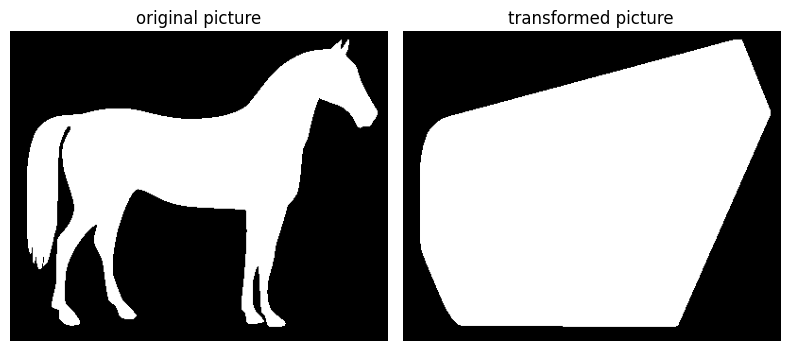

In [14]:
import matplotlib.pyplot as plt
from skimage.morphology import convex_hull_image
from skimage import data, img_as_float
from skimage.util import invert

# The original image is inverted as the object must be white.
image = invert(data.horse())
chull = convex_hull_image(image)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

ax = axes.ravel()
ax[0].set_title('original picture')
ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_axis_off()

ax[1].set_title('transformed picture')
ax[1].imshow(chull, cmap=plt.cm.gray)
ax[1].set_axis_off()

plt.tight_layout()
plt.show()

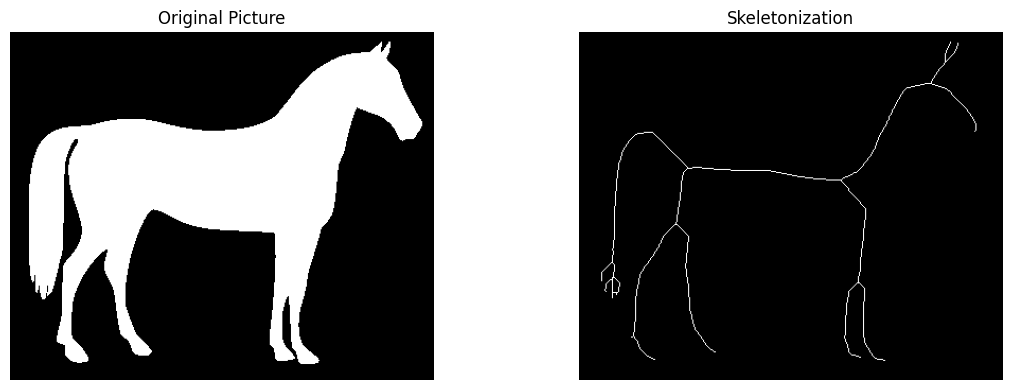

In [17]:
import matplotlib.pyplot as plt
from skimage.morphology import convex_hull_image, skeletonize
from skimage import data
from skimage.util import invert

# 1. Memuat dan menyiapkan data
# Gambar kuda diinversi karena objek harus berwarna putih (1) dan background hitam (0)
image = invert(data.horse())

# 2. Melakukan transformasi morfologi
chull = convex_hull_image(image)    # Membuat area cembung terkecil yang membungkus objek
skeleton = skeletonize(image)       # Membuat kerangka objek setebal 1 piksel

# 3. Menampilkan hasil dalam satu baris (2 kolom)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
ax = axes.ravel()

# Menampilkan Gambar Asli
ax[0].set_title('Original Picture')
ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_axis_off()

# Menampilkan Hasil Skeletonization
ax[1].set_title('Skeletonization')
ax[1].imshow(skeleton, cmap=plt.cm.gray)
ax[1].set_axis_off()

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Active Contour Image')

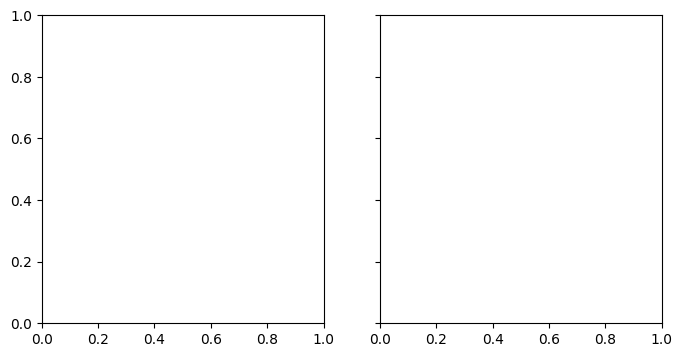

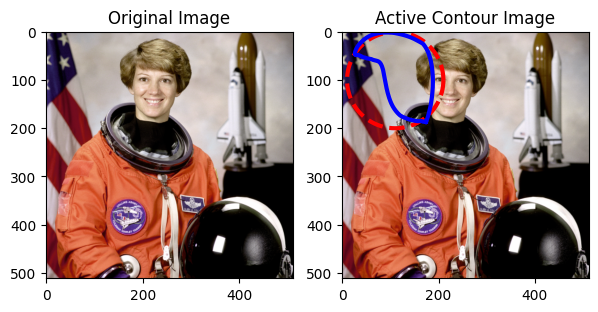

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.morphology import skeletonize
from skimage.util import invert
from skimage.color import rgb2gray
from skimage.filters import gaussian
from skimage.segmentation import active_contour

# Menampilkan hasil Skeletonization
fig_skel, axes_skel = plt.subplots(nrows=1, ncols=2, figsize=(8, 4), sharex=True, sharey=True)
ax_skel = axes_skel.ravel()

# --- BAGIAN 2: ACTIVE CONTOUR (SNAKES) ---
img_astro = data.astronaut()
# Mengubah ke grayscale jika diperlukan oleh fungsi tertentu,
# meski active_contour bisa menerima RGB (dengan filter gaussian)
img_gray = rgb2gray(img_astro)

# Data untuk inisialisasi lingkaran (boundary)
s = np.linspace(0, 2*np.pi, 400)
x = 110 + 100*np.cos(s)
y = 100 + 100*np.sin(s)
init = np.array([x, y]).T

# Pembentukan active contour
# Menggunakan filter gaussian untuk menghaluskan gambar agar algoritma bekerja lebih baik
cntr = active_contour(gaussian(img_astro, sigma=3, channel_axis=-1),
                      init, alpha=0.015, beta=10, gamma=0.001)

# Menampilkan hasil Active Contour
fig_ac, ax_ac = plt.subplots(1, 2, figsize=(7, 7))

ax_ac[0].imshow(img_astro, cmap=plt.cm.gray)
ax_ac[0].set_title("Original Image")

ax_ac[1].imshow(img_astro, cmap=plt.cm.gray)
# Menampilkan garis inisialisasi (merah putus-putus)
ax_ac[1].plot(init[:, 0], init[:, 1], '--r', lw=3)
# Menampilkan garis hasil akhir active contour (biru)
ax_ac[1].plot(cntr[:, 0], cntr[:, 1], '-b', lw=3)
ax_ac[1].set_title("Active Contour Image")


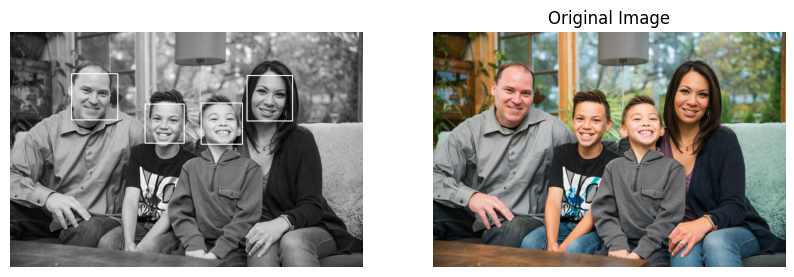

In [24]:
import io
import zipfile
import requests
import numpy as np
import cv2
import matplotlib.pyplot as plt

%matplotlib inline
img = cv2.imread('/content/sample_data/family-portrait.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
path ='/content/sample_data/haarcascade_frontalface_default.xml'

face_cascade = cv2.CascadeClassifier(path)
for x, y, w, h in face_cascade.detectMultiScale(gray, 1.3):
  cv2.rectangle(gray, (x, y), (x + w, y + h), (255, 0, 0), 2)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(gray,cmap=plt.cm.gray)
ax[0].set_axis_off()

# The second subplot ax[1] is currently unused. If you want to display the original
# image here, you could add:
ax[1].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax[1].set_title('Original Image')
ax[1].set_axis_off()
plt.show()